<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### Выполнил Мерочкин Илья

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [22]:
import pandas as pd
import numpy as np
from time import time
import xgboost as xgb
import lightgbm as lgb

from category_encoders import TargetEncoder

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from catboost import CatBoostRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA


RANDOM_STATE = 42

In [16]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [17]:
valid_categories = {
    'experience_level': ['SE', 'MI', 'EN', 'EX'],
    'employment_type': ['FT', 'PT', 'CT', 'FL'],
    'remote_ratio': [0, 50, 100],
    'company_size': ['S', 'M', 'L']
}

for col, valid_values in valid_categories.items():
    if col in df.columns:
        invalid_values = set(df[col].unique()) - set(valid_values)
        if invalid_values:
            print(f"{col} содержит ошибочные значения: {invalid_values}")
        else:
            print(f"{col} не содержит ошибочных значений")

experience_level не содержит ошибочных значений
employment_type не содержит ошибочных значений
remote_ratio не содержит ошибочных значений
company_size не содержит ошибочных значений


## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


Проблем в данных нет - пропуски отсутствуют

## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [19]:
df.shape

(3755, 11)

In [20]:
df.nunique()

,0
work_year,4
experience_level,4
employment_type,4
job_title,93
salary,815
salary_currency,20
salary_in_usd,1035
employee_residence,78
remote_ratio,3
company_location,72


In [21]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [22]:
df = df.drop(columns=['salary', 'salary_currency'])
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,CA,100,CA,M


Необходимо удалить колонки `salary` и `salary_currency`, так как `salary` по сути является той же самой целевой переменной (`salary_in_usd`), только выраженной в другой валюте, а фича `salary_currency` бесполезна. Остальные фичи выглядят волидными и полезными и пока что трудно сказать, какие из них нам помогут нам для решения задачи, поэтому их пока оставим.

## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [23]:
y = df['salary_in_usd']
X = df.drop('salary_in_usd', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (3004, 8), y_train shape: (3004,)
X_test shape: (751, 8), y_test shape: (751,)


## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [24]:
cat_features = ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
num_features = ['work_year']

X_train_cont = X_train[num_features]
X_test_cont = X_test[num_features]

## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [25]:
lr = LinearRegression()
lr.fit(X_train_cont, y_train)

y_pred_lr_cont = lr.predict(X_test_cont)

print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_lr_cont) * 100}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr_cont))}")

MAPE: 70.64709508683778
RMSE: 61358.08203594967


Модель показала плохое качество - ошибается в среднем на 70.647% и средняя ошибка предсказаний - 61358 долларов, что является плохим результатом.

## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [26]:
cb = CatBoostRegressor(random_state=RANDOM_STATE)
cb.fit(X_train_cont, y_train)

y_pred_cb_cont = cb.predict(X_test_cont)

print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_cb_cont) * 100}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_cb_cont))}")

Learning rate set to 0.048714
0:	learn: 62909.9077782	total: 47.6ms	remaining: 47.5s
1:	learn: 62745.5644913	total: 48.1ms	remaining: 24s
2:	learn: 62595.4946619	total: 48.5ms	remaining: 16.1s
3:	learn: 62459.2516100	total: 48.8ms	remaining: 12.2s
4:	learn: 62336.1170163	total: 49.3ms	remaining: 9.8s
5:	learn: 62223.8042233	total: 49.7ms	remaining: 8.23s
6:	learn: 62122.3078981	total: 50.1ms	remaining: 7.11s
7:	learn: 62050.0264974	total: 50.5ms	remaining: 6.26s
8:	learn: 61964.1773346	total: 50.9ms	remaining: 5.61s
9:	learn: 61886.6061223	total: 51.4ms	remaining: 5.08s
10:	learn: 61816.2115810	total: 51.9ms	remaining: 4.67s
11:	learn: 61752.0870833	total: 52.3ms	remaining: 4.31s
12:	learn: 61693.9469348	total: 52.7ms	remaining: 4s
13:	learn: 61641.4034988	total: 53.1ms	remaining: 3.74s
14:	learn: 61593.5855474	total: 53.5ms	remaining: 3.51s
15:	learn: 61550.3626555	total: 54ms	remaining: 3.32s
16:	learn: 61511.1596434	total: 54.5ms	remaining: 3.15s
17:	learn: 61475.4991239	total: 55ms

Бустинг также показал плохой результат - 70.655% ошибок и средняя ошибка предсказаний - 61617 долларов

## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [27]:
preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_features)
    ]
)

X_train_ohe = preprocessor_ohe.fit_transform(X_train)
X_test_ohe = preprocessor_ohe.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_ohe, y_train)
y_pred_lr_cont = lr.predict(X_test_ohe)
print(f"MAPE with LinearRegression: {mean_absolute_percentage_error(y_test, y_pred_lr_cont) * 100}")
print(f"RMSE with LinearRegression: {np.sqrt(mean_squared_error(y_test, y_pred_lr_cont))}")


cb = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)
cb.fit(X_train_ohe, y_train)
y_pred_cb_cont = cb.predict(X_test_ohe)
print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred_cb_cont) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred_cb_cont))}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


MAPE with LinearRegression: 40.340867305811706
RMSE with LinearRegression: 49802.0463551109
MAPE with catboost: 36.34634712642949
RMSE with catboost: 48430.76138862407


In [28]:
X_train_label = X_train.copy()
X_test_label = X_test.copy()
for col in cat_features:
    le = LabelEncoder()
    X_train_label[col] = le.fit_transform(X_train_label[col])
    X_test_label[col] = X_test_label[col].map(lambda x: -1 if x not in le.classes_ else x)

    mask = X_test_label[col] != -1
    X_test_label.loc[mask, col] = le.transform(X_test_label.loc[mask, col])


lr = LinearRegression()
lr.fit(X_train_label, y_train)
y_pred_lr_cont = lr.predict(X_test_label)
print(f"MAPE with LinearRegression: {mean_absolute_percentage_error(y_test, y_pred_lr_cont) * 100}")
print(f"RMSE with LinearRegression: {np.sqrt(mean_squared_error(y_test, y_pred_lr_cont))}")


cb = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)
cb.fit(X_train_label, y_train)
y_pred_cb_cont = cb.predict(X_test_label)
print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred_cb_cont) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred_cb_cont))}")

MAPE with LinearRegression: 49.72777094588221
RMSE with LinearRegression: 53263.35030903569
MAPE with catboost: 41.67135452922137
RMSE with catboost: 48835.49280449569


In [29]:
X_train_target = X_train.copy()
X_test_target = X_test.copy()

te = TargetEncoder(cols=cat_features)
X_train_target = te.fit_transform(X_train_target, y_train)
X_test_target = te.transform(X_test_target)

lr = LinearRegression()
lr.fit(X_train_target, y_train)
y_pred_lr_cont = lr.predict(X_test_target)
print(f"MAPE with LinearRegression: {mean_absolute_percentage_error(y_test, y_pred_lr_cont) * 100}")
print(f"RMSE with LinearRegression: {np.sqrt(mean_squared_error(y_test, y_pred_lr_cont))}")


cb = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)
cb.fit(X_train_target, y_train)
y_pred_cb_cont = cb.predict(X_test_target)
print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred_cb_cont) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred_cb_cont))}")

MAPE with LinearRegression: 39.280339583750674
RMSE with LinearRegression: 48862.72159413696
MAPE with catboost: 42.20115835637701
RMSE with catboost: 48409.358784949545


1) Тут модели показали уже лучше качество, чем было раньше. MAPE снизилась с 70% до 40% на линейной регрессии и 36% на катбусте. RMSE снизился примерно на 12000 долларов, но все еще остается высоким.
2) С использованием `LabelEncoder` модель показала качество лучше, чем было на числовых данных: MAPE снизилась с 70% до 50% на линейной регрессии и 41.5% на катбусте, RMSE снизился примерно на 8000 долларов на линейной регрессии и 12000 долларов на катбусте. Однако предобработка с `LabelEncoder` показала результат хуже, чем с OHE.
3) С использованием `TargetEncoder` модель показал качество лучше, чем было на числовых данных: MAPE снизилась с 70% до 39% на линейной регрессии и 42% на катбусте, RMSE снизился примерно на 12000 долларов на обеих моделях.

Самое лучшее качество показал катбуст с кодированием, через OHE, поэтому далее будем пользоваться им.

## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [30]:
cb = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)
cb.fit(X_train_ohe, y_train)
y_pred_cb_cont = cb.predict(X_test_ohe)
print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred_cb_cont) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred_cb_cont))}")

MAPE with catboost: 36.34634712642949
RMSE with catboost: 48430.76138862407


In [31]:
final_table = X_test.copy()
final_table['actual_value'] = y_test
final_table['predicted_value'] = y_pred_cb_cont
final_table['error_diff'] = abs(y_test - y_pred_cb_cont)

most_inaccurate = final_table.sort_values('error_diff', ascending=False).iloc[:20]

most_inaccurate

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,actual_value,predicted_value,error_diff
1288,2023,SE,FT,Data Analyst,US,0,US,M,385000,129309.884996,255690.115004
2359,2022,SE,FT,Data Science Tech Lead,US,50,US,L,375000,154232.508066,220767.491934
1105,2023,SE,FT,Data Scientist,US,0,US,M,370000,168532.328466,201467.671534
218,2023,SE,FT,Applied Data Scientist,AU,100,FI,M,68318,225974.734528,157656.734528
3609,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S,260000,105702.326086,154297.673914
478,2023,EX,FT,Director of Data Science,US,0,US,M,353200,200263.868030,152936.131970
1116,2023,SE,FT,Machine Learning Engineer,US,0,US,M,323300,178124.780565,145175.219435
33,2023,SE,FT,Computer Vision Engineer,US,0,US,M,342810,201419.294433,141390.705567
1593,2023,SE,FT,Data Engineer,US,0,US,M,300000,158722.369752,141277.630248
2009,2022,SE,FT,Machine Learning Engineer,MX,100,MX,M,255000,115867.540968,139132.459032


- Во всех 20 семплах employment_type = `FT`
- Для большинства строка из найденных 20 страна - `US`
- В размере компании преобладает `M`
- В ошибке модель, как правило, преуменьшает целевую переменную

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [67]:
X_train_enriched = X_train.copy()
X_test_enriched = X_test.copy()

job_counts = X_train_enriched['job_title'].value_counts().to_dict()

X_train_enriched['job_frequency'] = X_train_enriched['job_title'].map(job_counts)
X_test_enriched['job_frequency'] = X_test_enriched['job_title'].map(job_counts).fillna(1)

exp_mapping = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
X_train_enriched['experience_score'] = X_train_enriched['experience_level'].map(exp_mapping)
X_test_enriched['experience_score'] = X_test_enriched['experience_level'].map(exp_mapping)

X_train_enriched['exp_remote_interaction'] = X_train_enriched['experience_score'] * (X_train_enriched['remote_ratio'] / 100 + 1)
X_test_enriched['exp_remote_interaction'] = X_test_enriched['experience_score'] * (X_test_enriched['remote_ratio'] / 100 + 1)

X_train_enriched = X_train_enriched.drop('experience_score', axis=1)
X_test_enriched = X_test_enriched.drop('experience_score', axis=1)

preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['work_year', 'job_frequency', 'exp_remote_interaction']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_features)
    ]
)

X_train_enriched_ohe = preprocessor_ohe.fit_transform(X_train_enriched)
X_test_enriched_ohe = preprocessor_ohe.transform(X_test_enriched)

cb = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)
cb.fit(X_train_enriched_ohe, y_train)
y_pred = cb.predict(X_test_enriched_ohe)
print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred))}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


MAPE with catboost: 35.90708144439215
RMSE with catboost: 47913.86309564278


Было добавлено 2 новые фичи:
- Популярность работы
- Фича, основанная на умножении уровня опыта и статуса удаленки

MAPE удалось снизить с 36.35 до 35.91  
RMSE удалось снизить с 48431 до 47914

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [ ]:
param_grid = {
    'iterations': [500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64],
    'cat_features': [cat_features]
}

cb = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='MAPE',
    verbose=0,
    random_state=RANDOM_STATE
)

gs = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

start = time()
gs.fit(X_train, y_train)
finish = time()

print(f"Time on 1 fold: {(finish - start)/432}")
print(f"Best params with raw data: {gs.best_params_}")
print(f"Best MAPE on cross-validation with raw data: {-gs.best_score_ * 100}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Time on 1 fold: 2.3518732714432256
Best params with raw data: {'border_count': 32, 'cat_features': ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size'], 'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best MAPE on cross-validation with raw data: 36.634678588233776


In [ ]:
cb = CatBoostRegressor(
    cat_features=cat_features,
    border_count=32,
    depth=4,
    iterations=500,
    l2_leaf_reg=2,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=0
)

start = time()
cb.fit(X_train, y_train)
finish = time()
print(f"Время затраченное на обучение {finish - start}")

start = time()
y_pred = cb.predict(X_test)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Время затраченное на обучение 0.9924709796905518
Время затраченное на предикт 0.004745006561279297
MAPE with catboost: 40.48980409209028
RMSE with catboost: 47754.20777328751


In [ ]:
param_grid = {
    'iterations': [500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64]
}

cb = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='MAPE',
    verbose=0,
    random_state=RANDOM_STATE
)

gs = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

start = time()
gs.fit(X_train_ohe, y_train)
finish = time()

print(f"Time on 1 fold: {(finish - start)/432}")
print(f"Best params with ohe: {gs.best_params_}")
print(f"Best MAPE on cross-validation with ohe: {-gs.best_score_ * 100}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Time on 1 fold: 0.45707777584040604
Best params with ohe: {'border_count': 32, 'depth': 6, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best MAPE on cross-validation with ohe: 35.66693500126112


In [ ]:
cb = CatBoostRegressor(
    border_count=32,
    depth=6,
    iterations=500,
    l2_leaf_reg=1,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=0
)

start = time()
cb.fit(X_train_ohe, y_train)
finish = time()
print(f"Время затраченное на обучение {finish - start}")

start = time()
y_pred = cb.predict(X_test_ohe)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

print(f"MAPE with catboost: {mean_absolute_percentage_error(y_test, y_pred) * 100}")
print(f"RMSE with catboost: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Время затраченное на обучение 0.901090145111084
Время затраченное на предикт 0.004338979721069336
MAPE with catboost: 36.186000192384796
RMSE with catboost: 48951.24489384777


В данном задании мы пробовали два подбора лучших гиперпараметров:
- С исходными "сырыми" данными с обработкой категориальный фичей самим катбустом:
    - Время на обучение одного фолда в среднем 2.35с
    - MAPE на лучших гиперпараметрах - 40.5
    - RMSE на лучших гиперпараметрах - 47754
- С данными, где категориальные фичи закодированы через ohe
    - Время на обучение одного фолда в среднем 0.46с
    - MAPE на лучших гиперпараметрах - 36.19
    - RMSE на лучших гиперпараметрах - 48951

## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [35]:
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_lambda': [1, 3, 5]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    verbosity=0
)

gs = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

start = time()
gs.fit(X_train_ohe, y_train)
finish = time()

print(f"Time on 1 fold: {(finish - start)/432}")
print(f"Best params with ohe: {gs.best_params_}")
print(f"Best MAPE on cross-validation with ohe: {-gs.best_score_ * 100}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Time on 1 fold: 0.5670550664265951
Best params with ohe: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.7}
Best MAPE on cross-validation with ohe: 35.33661564191182


In [37]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=5,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    verbosity=0
)

start = time()
xgb_model.fit(X_train_ohe, y_train)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

start = time()
y_pred = xgb_model.predict(X_test_ohe)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

print(f"MAPE with xgboost: {mean_absolute_percentage_error(y_test, y_pred) * 100}")
print(f"RMSE with xgboost: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Время затраченное на предикт 0.8010821342468262
Время затраченное на предикт 0.009361505508422852
MAPE with xgboost: 35.70922017097473
RMSE with xgboost: 48079.02561408665


При подборе лучших гиперпараметров xgboost-а были найдены следующие:
- n_estimators = 200
- max_depth = 7
- learning_rate = 0.05
- subsample = 0.7
- colsample_bytree = 0.7
- reg_lambda = 5

Модель показала следующие результаты:
- MAPE = 35.71
- RMSE = 48079
- Время обучения одного фолда = 0.57

В итоге xgboost обучался быстрее, чем катбуст и показал лучше MAPE, однако RMSE оказался хуже

## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [55]:
param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.03, 0.1],
    'num_leaves': [30, 60],
    'reg_lambda': [1, 3, 5]
}

lgb_model = lgb.LGBMRegressor(
    objective='regression',
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1
)

gs = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

start = time()
gs.fit(X_train_ohe, y_train)
finish = time()

print(f"Time on 1 fold: {(finish - start)/324}")
print(f"Best params with ohe: {gs.best_params_}")
print(f"Best MAPE on cross-validation with ohe: {-gs.best_score_ * 100}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Time on 1 fold: 0.7468556415887526
Best params with ohe: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 30, 'reg_lambda': 1}
Best MAPE on cross-validation with ohe: 35.86943108116072


In [59]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    num_leaves=30,
    reg_lambda=1,
    objective='regression',
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1
)

start = time()
lgb_model.fit(X_train_ohe, y_train)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

start = time()
y_pred = lgb_model.predict(X_test_ohe)
finish = time()
print(f"Время затраченное на предикт {finish - start}")

print(f"MAPE with lgb: {mean_absolute_percentage_error(y_test, y_pred) * 100}")
print(f"RMSE with lgb: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Время затраченное на предикт 0.21501779556274414
Время затраченное на предикт 0.0170590877532959
MAPE with lgb: 36.50396983757813
RMSE with lgb: 48846.7622102937


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


При подборе лучших гиперпараметров lgb были найдены следующие:
- n_estimators = 500
- max_depth = 3
- learning_rate = 0.1
- num_leaves = 30
- reg_lambda = 1

Модель показала следующие результаты:
- MAPE = 36.5
- RMSE = 48847
- Время обучения одного фолда = 0.75

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

Разные модели показали разные результаты и сложно однозначно сказать, что какая-то из них лучше, а какая-то хуже. Укажу критерии и укажу модели от лучшей, к худжей в зависимости от результатов, которые они показали.

Время обучения (указываю среднее время на 1 фолд):
1) Сatboost с ohe - 0.46
2) Xgboost - 0.57
3) lgb - 0.75
4) Catboost с их обработкой категориальных фичей - 2.35

MAPE:
1) Xgboost -  35.71
2) Catboost с ohe - 36.18
3) lbg - 36.5
4) Catboost с их обработкой категориальных фичей - 40.49

RMSE:
1) Catboost с их обработкой категориальных фичей - 47754.2
2) Xgboost - 48079
3) lbg - 48846
4) Catboost с ohe - 48951

Модель необходимо выбирать в зависимости от проблемы, которую мы хотим решить. И по данным метрикам можем видеть, что разные модель по-разному хороши в разных показателях. Но если уж выбрать ту, которая показала себя лучше в совокупности всех факторов - Xgboost.

Бустинг превзошел обычные линейные модели, поэтому его использование можно считать целесообразным.

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [44]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [15]:
X_train = pd.read_csv('samsung_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv('samsung_train_labels.txt', sep=r'\s+', header=None)

X_test = pd.read_csv('samsung_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv('samsung_test_labels.txt', sep=r'\s+', header=None)

X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

In [18]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [20]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [26]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_.sum())
X_pca.shape

0.9004833346822928


(10299, 65)

### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

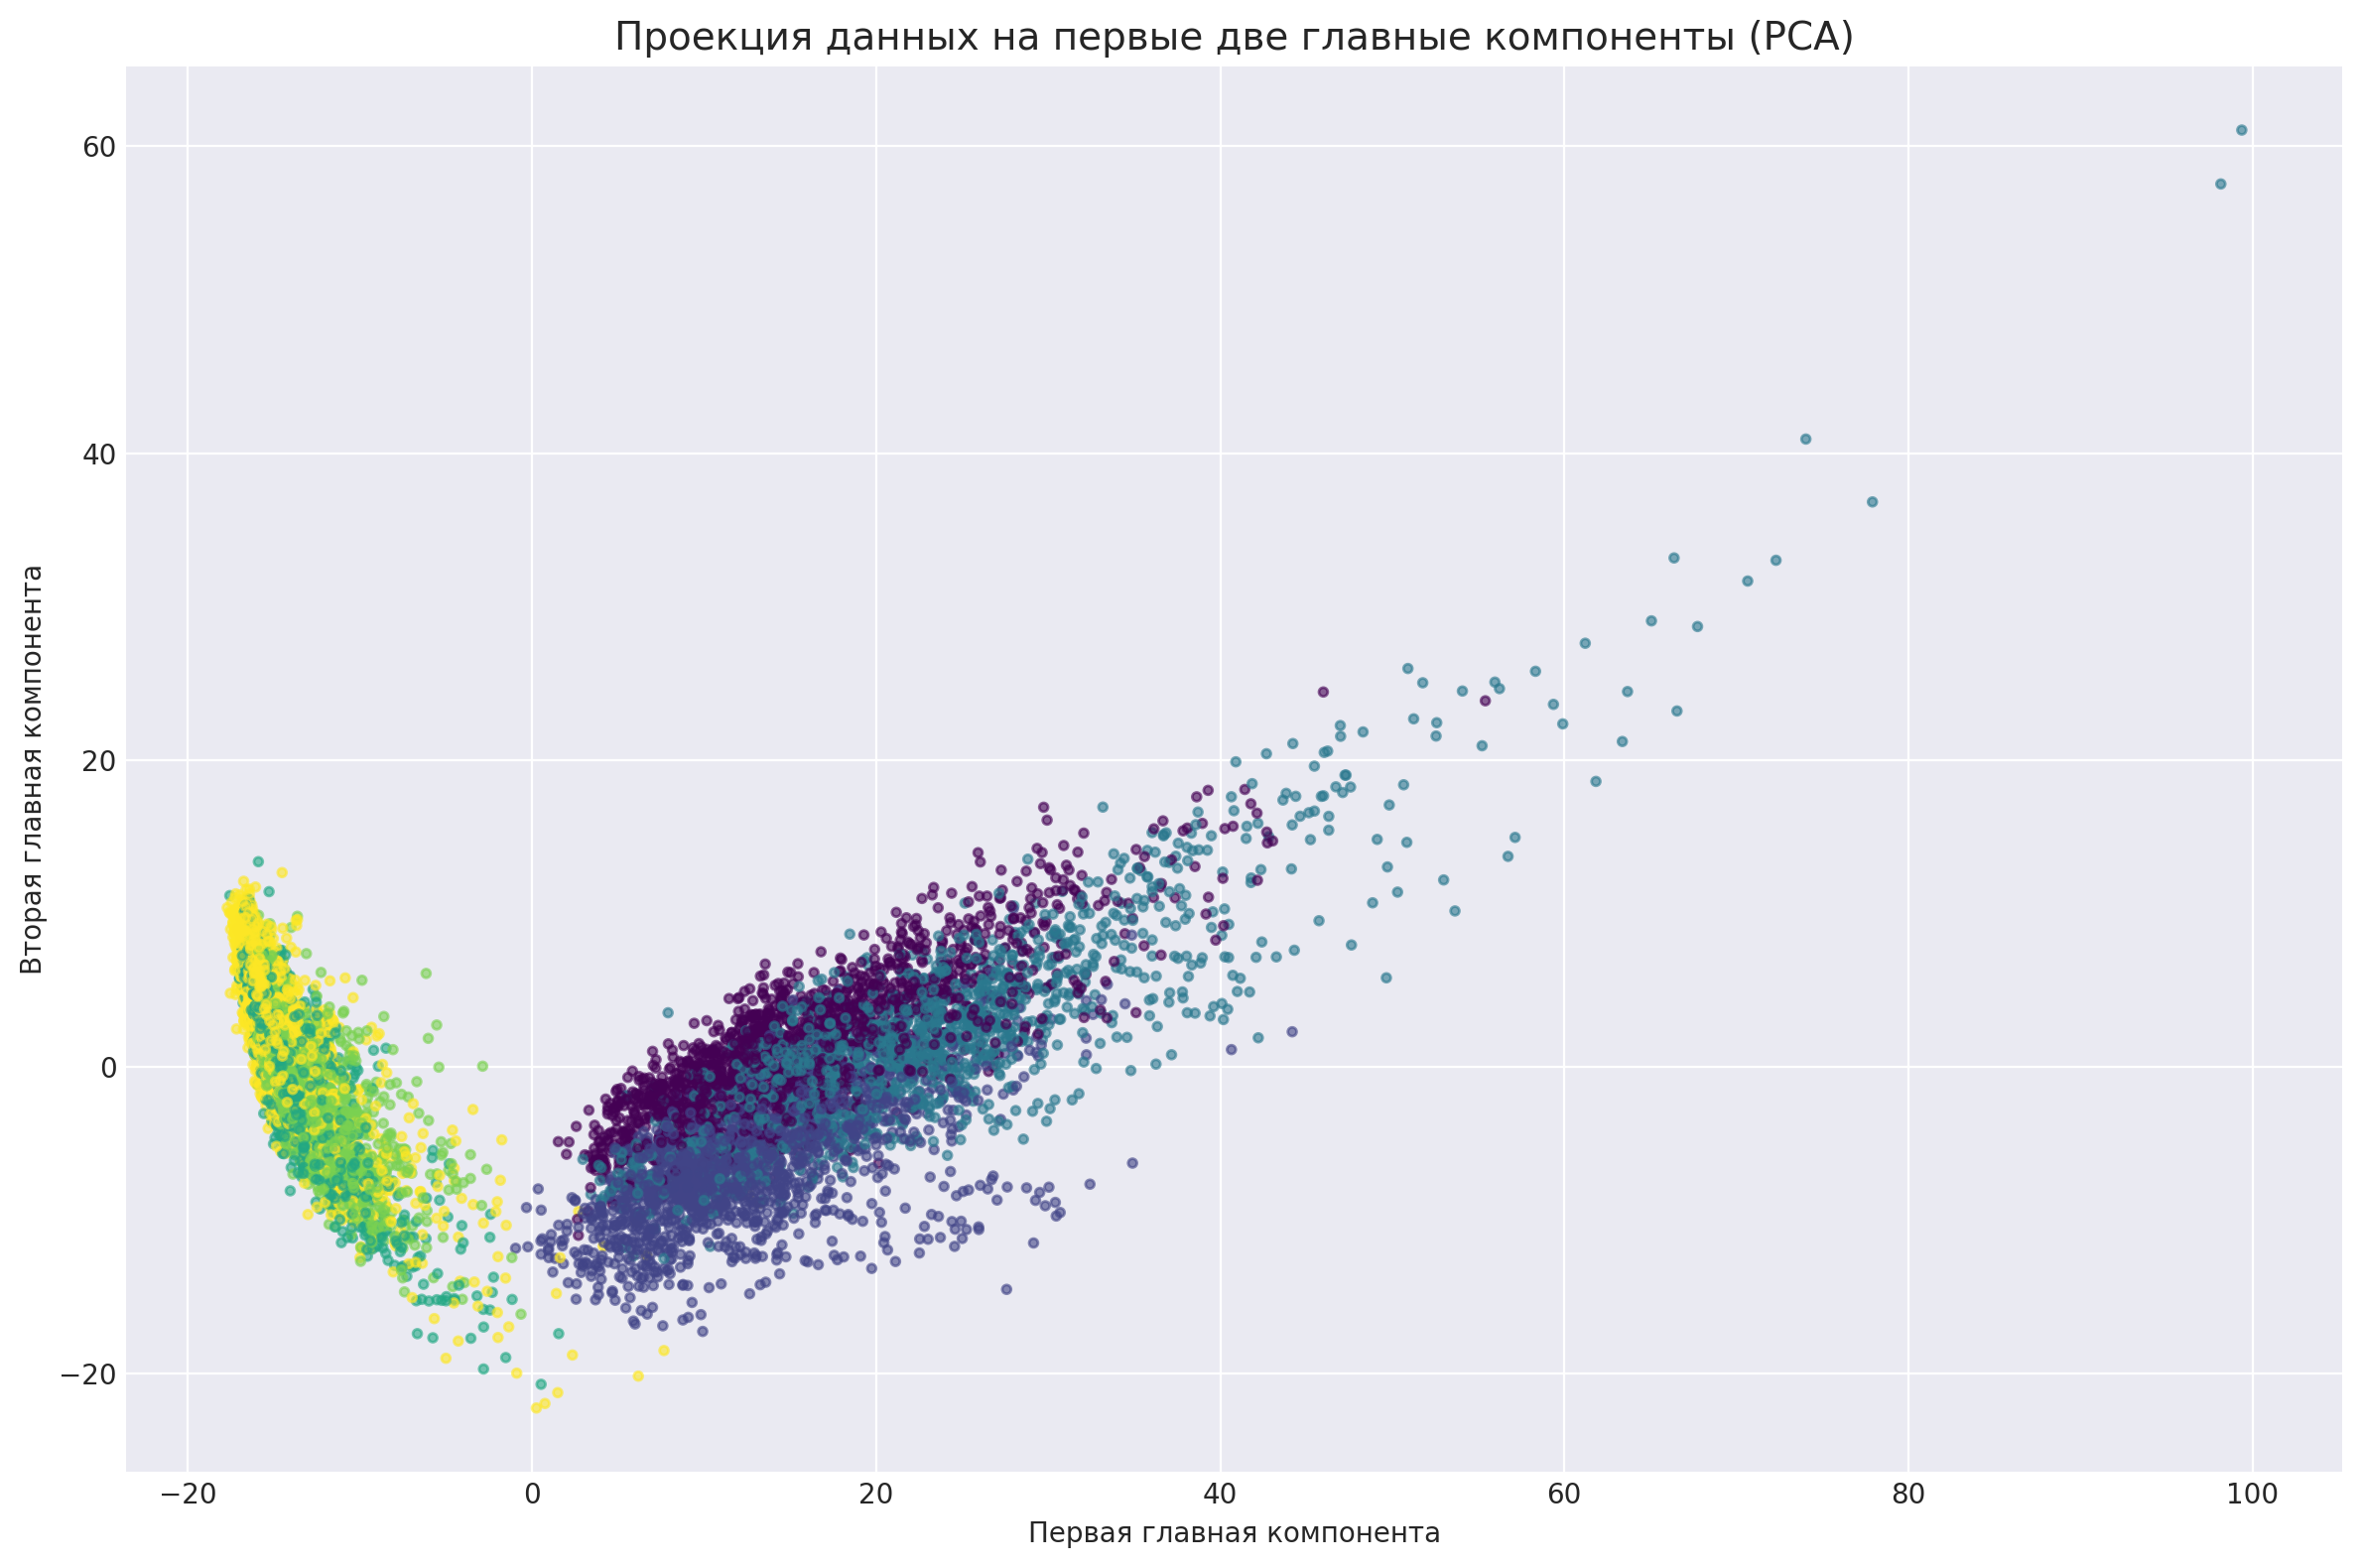

In [35]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.6,
    s=10,
)

plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [34]:
kmeans = KMeans(
    n_clusters=6,
    n_init=100,
    random_state=RANDOM_STATE,
)

start_fit_time = time()
kmeans.fit(X_pca)
end_fit_time = time()

start_pred_time = time()
y_pred = kmeans.predict(X_pca)
end_pred_time = time()

print(f"Время обучения: {end_fit_time - start_fit_time}")
print(f"Время предикта: {end_pred_time - start_pred_time}")

Время обучения: 12.294021606445312
Время предикта: 0.004873991012573242


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

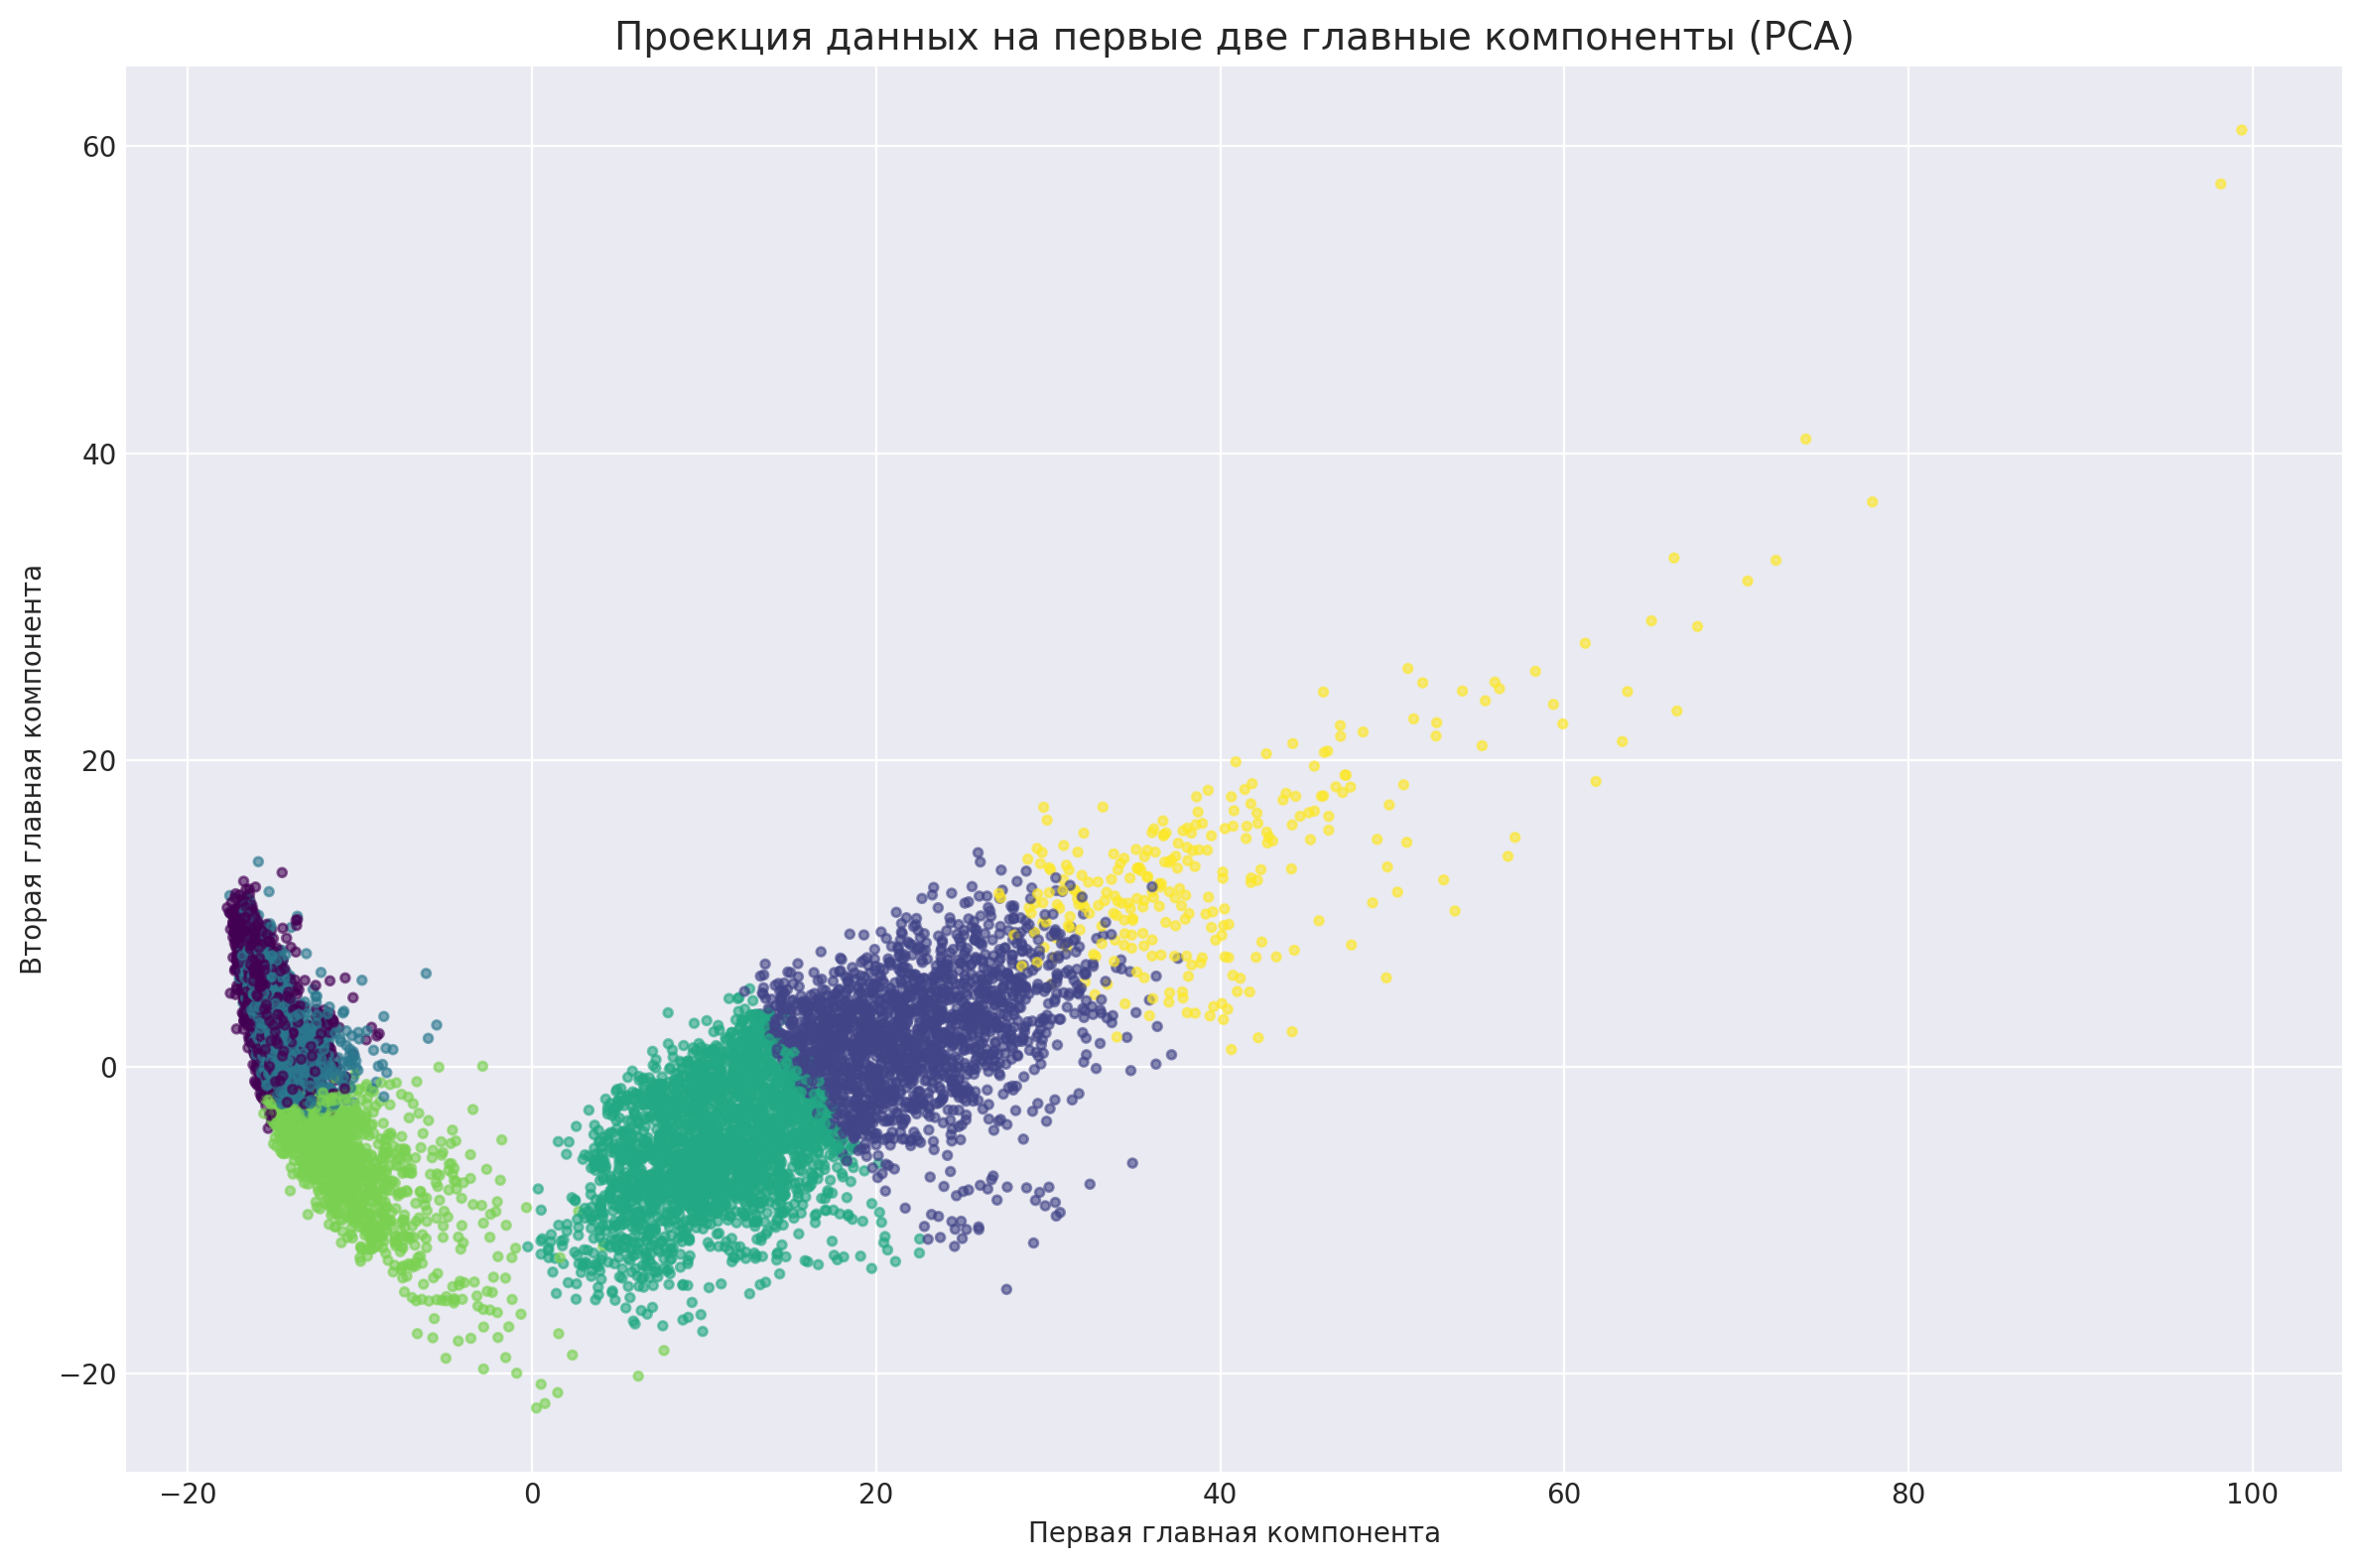

In [36]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred,
    cmap='viridis',
    alpha=0.6,
    s=10,
)

plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [43]:
print(f"ARI score: {adjusted_rand_score(np.ravel(y), y_pred)}")
print(f"NMI score: {normalized_mutual_info_score(np.ravel(y), y_pred)}")

ARI score: 0.4194956465790897
NMI score: 0.5600410921019028


В качестве метрик были выбрана ARI и NMI.  

Данные метрики оценивают качество кластеризации через степень соответствия полученных кластеров эталонным разбиениям, при этом они нечувствительны к произвольной нумерации кластеров.  

Они показали результат ниже среднего, ARI = 0.42 говорит о том, что только 42% пар объектов сгруппированы правильно относительно реальных классов, а NMI = 0.56 означает, что кластеры сохраняют 56% информации о реальных классах. Поэтому необходимо изменить решение.

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

Время обучения: 12.614014387130737


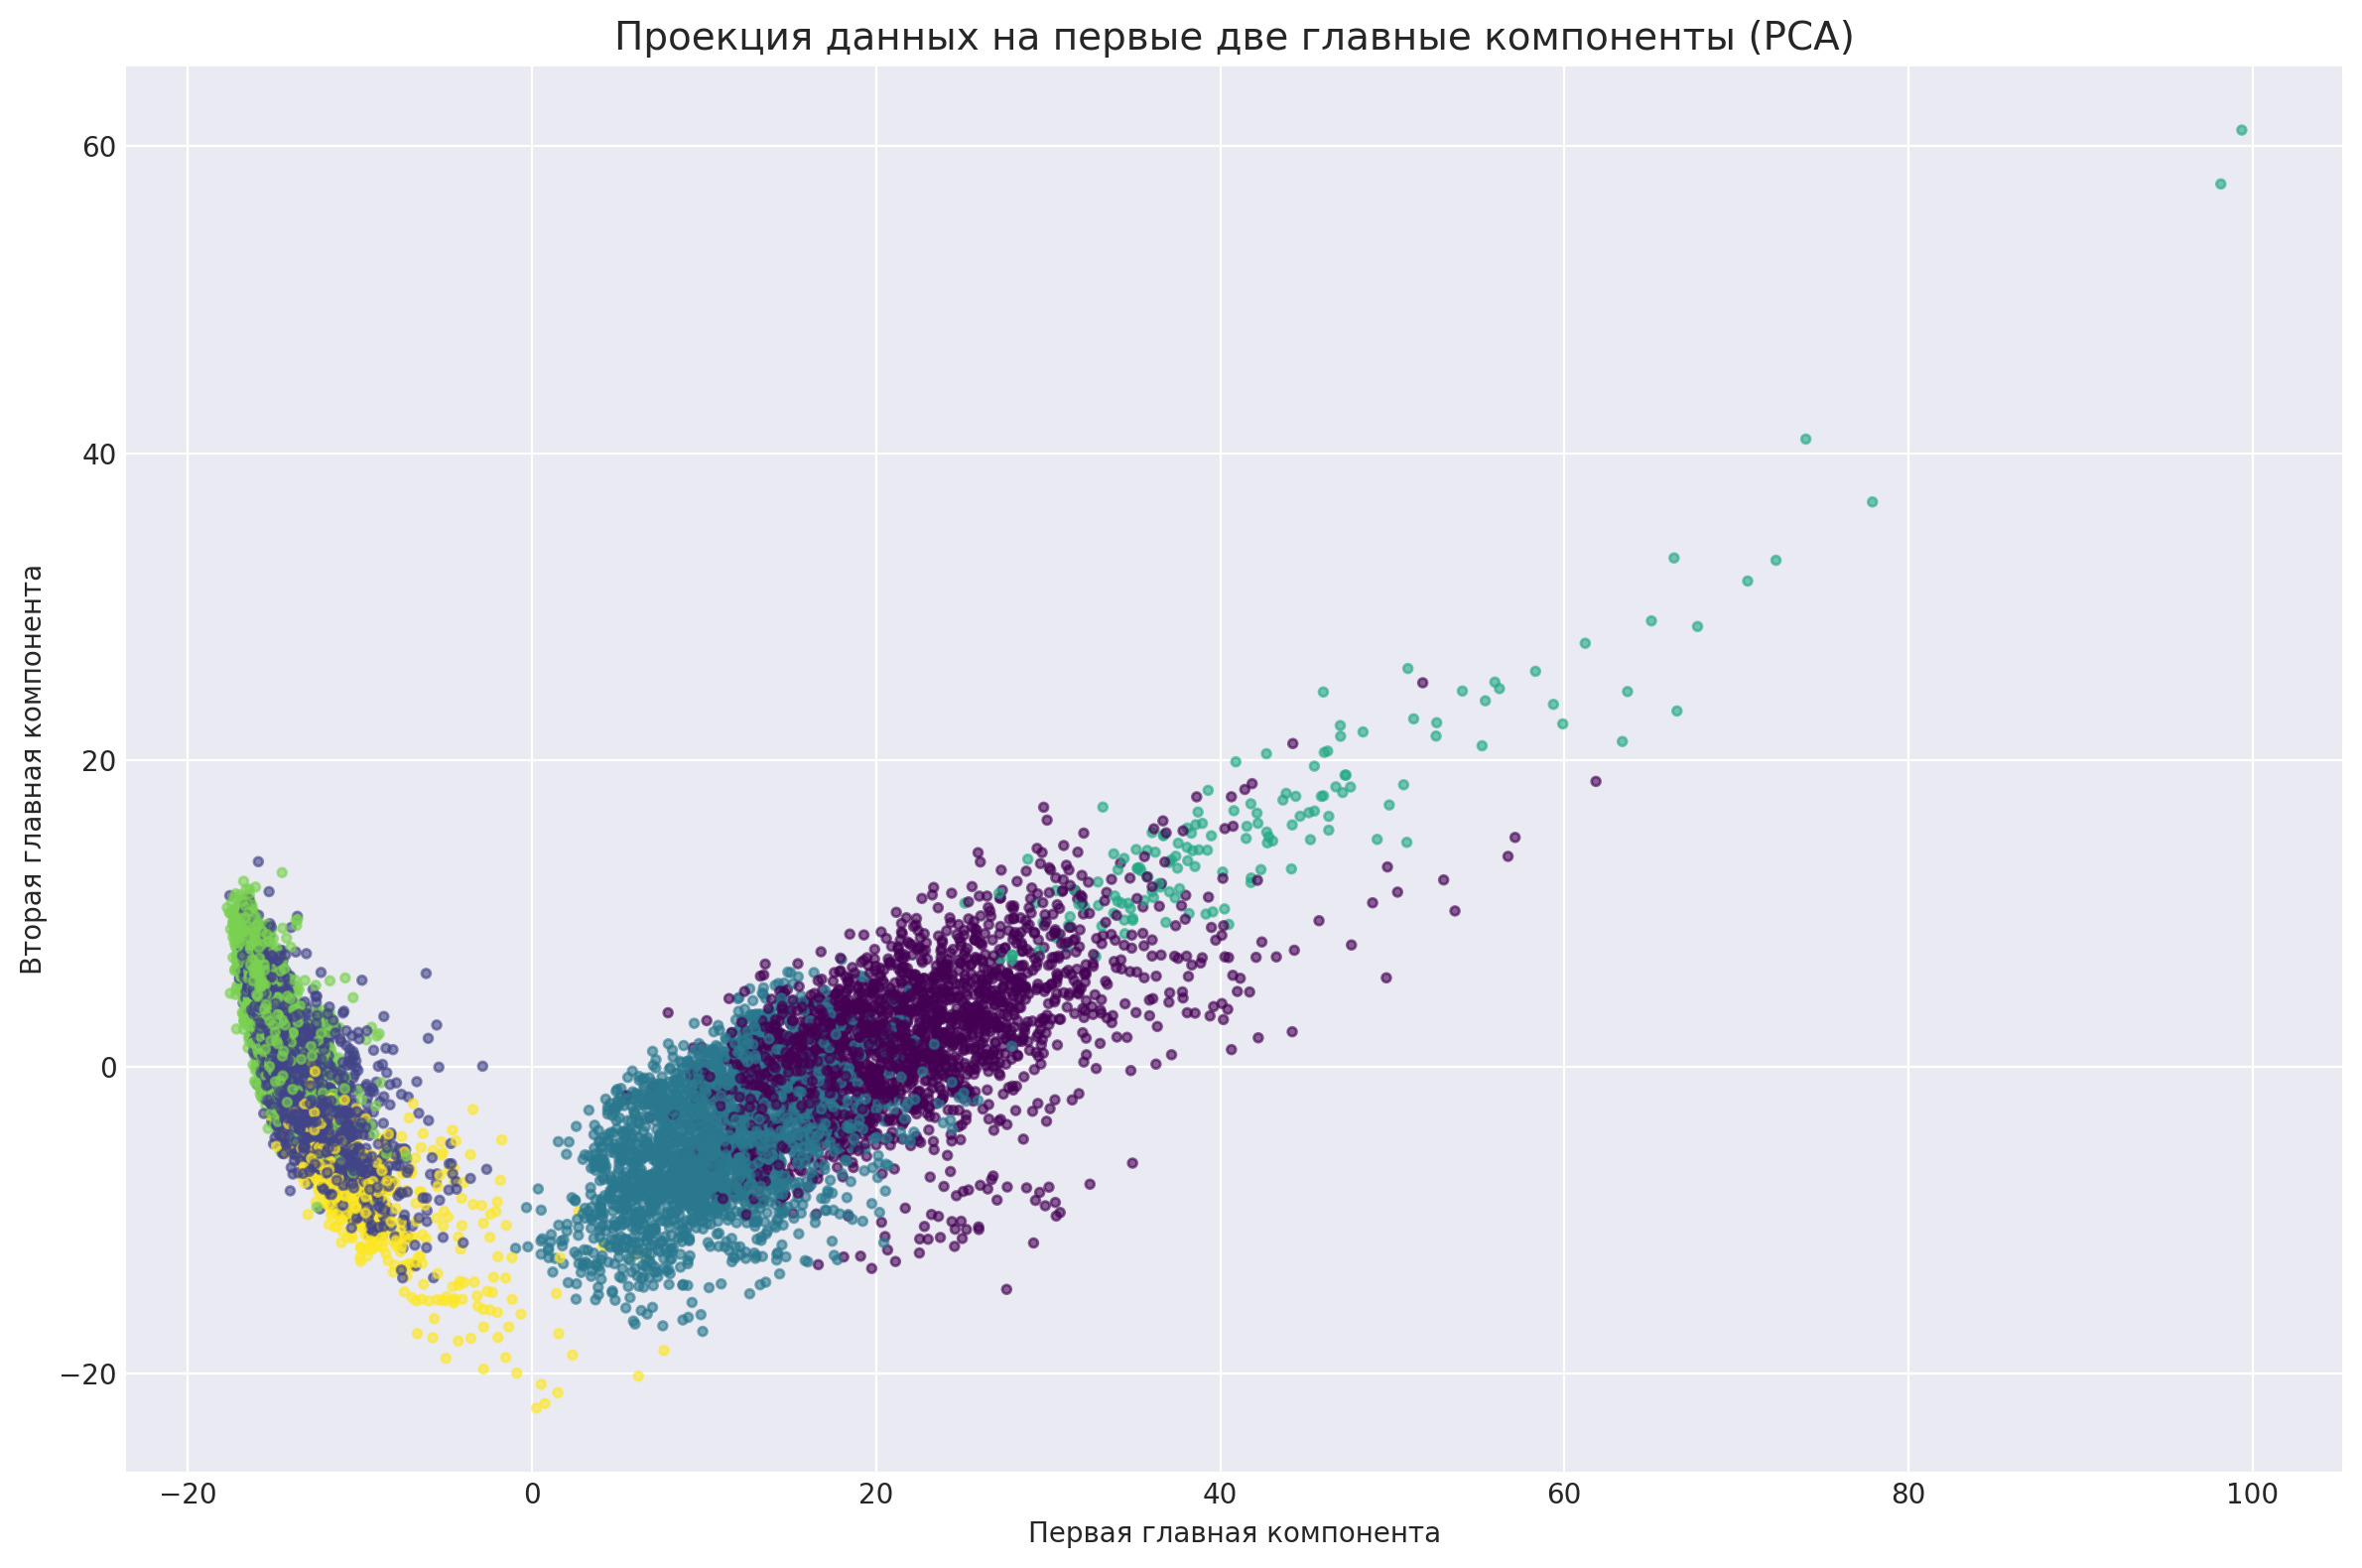

ARI score: 0.49362763373004886
NMI score: 0.6217855076000529


In [51]:
agg_clustering = AgglomerativeClustering(n_clusters=6)

start_fit_time = time()
agg_clustering.fit(X_pca)
end_fit_time = time()

y_pred = agg_clustering.labels_

print(f"Время обучения: {end_fit_time - start_fit_time}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred,
    cmap='viridis',
    alpha=0.6,
    s=10,
)

plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"ARI score: {adjusted_rand_score(np.ravel(y), y_pred)}")
print(f"NMI score: {normalized_mutual_info_score(np.ravel(y), y_pred)}")

При использовании `AgglomerativeClustering` стало лучше по сравнению с `KMeans`:
- ARI: 0.42 -> 0.49
- NMI: 0.56 -> 0.62

Также сам график принадлежности объектов к кластерам у `AgglomerativeClustering` больше похож на исходный набор.  

Время обучения `KMeans` и `AgglomerativeClustering` примерно одинаковые (если не учитывать небольшую погрешность).  

Более успешная работа `AgglomerativeClustering` связана с исходными данными, а именно с формой, которую имеют кластеры - они имеют довольно вытяную форму и пересекаются друг с другом. А с нахождением таких кластеров `KMeans` справляется довольно плохо, в чем мы и убедились.

### **Задание 23 (0.3 балла)**
Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* Похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* В каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* Качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

По графикам можно сделать вывод, что кластеры, полученные с помощью агломеративной кластеризации достаточно похожи с исходными данными. Местами встречаются зоны, где смешаны сразу несколько типов актинвостей, например, на графике с исходными данными в левой части есть место, где смешаны сразу желтый, темно-зеленый и светло-зеленый. Это может быть связано с тем, что сами действия достаточно похожи, их фичи похожи, поэтому их довольно трудно разделить между собой (например, спуск по лестнице и подъем по лестнице).  
Учитывая тот факт, что кластеры в некоторых местах смешиваются кластеризация получилась довольно таки качественная.

## **Бонус-задание (1 балл)**
![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных задачах. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. В бонусе предлагаем вам попрактиковаться именно в этом на чудесной утке и совах (```duck.jpg``` и ```owls.jpg```)

### **(0.1 балл)**

- Откройте изображения, после чего визуализируйте их с помощью ```plt.imshow()```

In [ ]:
from PIL import Image
# or
#import cv2

### **(0.4 балла)**

Для каждого изображения, используя кластеризацию ```KMeans```, выделите компоненты, охарактеризовав каждый пиксель следующим образом: $$\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$$
 где
- $x_i$ и $y_i$ — координаты пикселя,
- $r_i, g_i, b_i$ — его цвет,
- $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

Примените полученную функцию, взяв следующие $\lambda$: 0.3 и 1.5 для ```duck.jpg``` и ```owls.jpg``` (или другие, но тогда с вас красивые результаты :) )

**Примечание:**
Число кластеров подберите разумным образом на свой вкус (в качестве нулевого приближения можно взять 3)

In [ ]:
def find_components(image, lmbd, n_clusters):
    #your code here

### **(0.4 балла)**

Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).


**Примечание:**

Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**Подсказка:**```skimage``` с его ```color``` и ```transform``` в этом помогут :)

Или же воспользуйтесь аналогичными средствами ```PIL``` или ```cv2```

In [ ]:
def spectral_segmentation(image, n_clusters, beta, eps):
    #your code here

### **(0.1 балл)**
Визуализируйте результаты сегментации (аналогично рисунку в начале задания 2) для обоих методов.

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

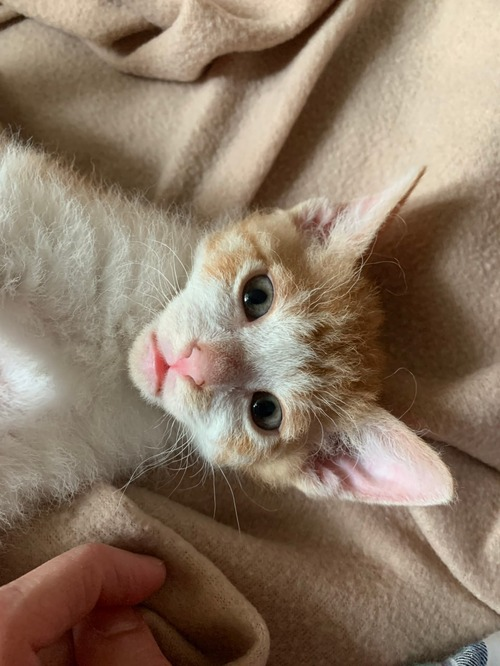